# 🔍 Credit Card Fraud Detection

## Project Outline

| Phase | Description |
|-------|-------------|
| 1. Problem Definition | What we're solving and why |
| 2. Data Collection | Dataset from Kaggle (284,807 transactions) |
| 3. Data Cleaning | Handling missing values, fixing data types |
| 4. EDA | Understanding data, visualizing fraud vs legit |
| 5. Feature Engineering | Scaling, new features, handling imbalance (SMOTE) |
| 6. Model Building | Using Machine Learning — Logistic Regression |
| 7. Model Testing | Testing model on unseen data, train/test split |
| 8. Evaluation | Precision, Recall, F1, ROC-AUC |
| 9. Conclusion | Best model, ethical considerations |

**Dataset:** [Credit Card Fraud Detection — Kaggle](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**Target:** Predict fraudulent transactions (Class: 0 = Legit, 1 = Fraud)

## Phase 1 — Problem Definition

Credit Card Fraud Detection is a binary classification problem where we predict 
whether a transaction is fraudulent (1) or legitimate (0).

Credit card fraud is a major financial threat causing billions of dollars in losses 
annually. Detecting fraud manually is impossible due to the sheer volume of 
transactions happening every second. This is where Machine Learning helps and can 
automatically detect suspicious patterns in transaction data.

The dataset is highly imbalanced -only 0.17% of transactions are fraud. This means 
a model that predicts everything as legitimate would still be 99.83% accurate, which 
is misleading. This is why we focus on Precision, Recall and F1 Score rather than 
plain accuracy.

Our goal is to build a Logistic Regression model that can correctly identify 
fraudulent transactions while minimizing false alarms.

In [5]:
# numpy - numerical and mathematical computations
import numpy as np

#data loading and manipulation
import pandas as pd

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#  machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# SMOTE - handling imbalanced data
from imblearn.over_sampling import SMOTE

## Phase 2 — Data Collection

The dataset is sourced from Kaggle — Credit Card Fraud Detection.
It contains 284,807 transactions made by European cardholders in September 2013.
Published by: Machine Learning Group, (ULB).

In [18]:
# loading the dataset
df = pd.read_csv('data/creditcard.csv')

# data's characterstics
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (284807, 31)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Phase 3 — Data Cleaning
Checking for missing values, duplicate rows and correct data types.

In [19]:
print("Missing Values:\n", df.isnull().sum())
# for missing values use mean for evenly distributed numerical data ,median for noticable outliers and mode for strings
# if missing valued rows is < 5% ,remove the row using df.dropna()
print("\nDuplicate Rows:", df.duplicated().sum())
# to remove duplicates using df.drop_duplicates()
print("\nData Types:\n",  all(df.dtypes != 'object'))
# use type casting for primitive data types , methods such as lower, strip , replace for typos ,toDate for dates

Missing Values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Duplicate Rows: 1081

Data Types:
 True


In [20]:
df = df.drop_duplicates()
print("Duplicates removed! New shape:", df.shape)

Duplicates removed! New shape: (283726, 31)


### Data Cleaning Results

- Missing Values: 0 — No missing values found, no action needed.
- Duplicate Rows: 1081 — Duplicates found and removed. New shape: (283726, 31)
- Data Types: All columns are numerical (float64/int64), no text columns found.

If any column had string/text data type, we would have used One Hot Encoding to 
convert them into numerical columns since Machine Learning models can only work 
with numbers.

Dataset is now clean and ready for Exploratory Data Analysis.

## Phase 4 — Exploratory Data Analysis (EDA)

EDA is the process of understanding our data before building any model.
We analyze the distribution of values, spot patterns and visualize relationships 
between variables.

In this phase we will check the statistical summary, visualize the class imbalance 
between fraud and legitimate transactions, and understand how Amount and Time 
are distributed across the dataset.

In [ ]:
df.describe()
# checking statstics of each attributes  

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [ ]:
df.info()
# information about dataset such as data types ,not null count and memory usage

<class 'pandas.DataFrame'>
Index: 283726 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    283726 non-null  float64
 1   V1      283726 non-null  float64
 2   V2      283726 non-null  float64
 3   V3      283726 non-null  float64
 4   V4      283726 non-null  float64
 5   V5      283726 non-null  float64
 6   V6      283726 non-null  float64
 7   V7      283726 non-null  float64
 8   V8      283726 non-null  float64
 9   V9      283726 non-null  float64
 10  V10     283726 non-null  float64
 11  V11     283726 non-null  float64
 12  V12     283726 non-null  float64
 13  V13     283726 non-null  float64
 14  V14     283726 non-null  float64
 15  V15     283726 non-null  float64
 16  V16     283726 non-null  float64
 17  V17     283726 non-null  float64
 18  V18     283726 non-null  float64
 19  V19     283726 non-null  float64
 20  V20     283726 non-null  float64
 21  V21     283726 non-null  f

In [16]:
# checking occuuence of of fraud vs legitimate transactions
print("Class Distribution:")
print(df['Class'].value_counts())
print("\nFraud Percentage:", round(df['Class'].mean() * 100, 2), "%")

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Fraud Percentage: 0.17 %


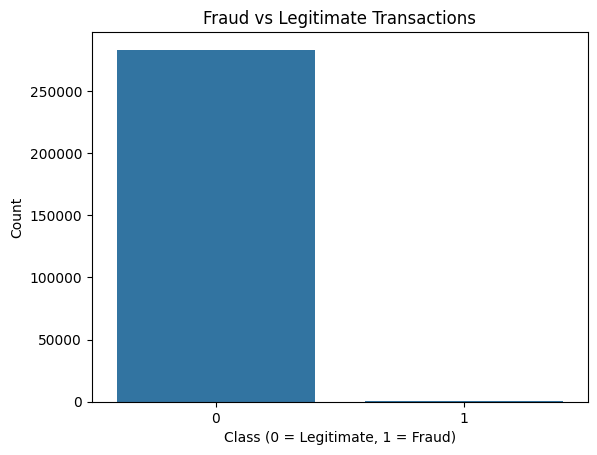

In [17]:
 # visualizing class imbalance
sns.countplot(x='Class', data=df)
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Count')
plt.show()

### Class Imbalance

The dataset is highly imbalanced:
- Legitimate transactions (Class 0): 99.83%
- Fraudulent transactions (Class 1): 0.17%

This means for every 1 fraud case there are approximately 578 legitimate transactions.
If not addressed, the model will only learn to predict everything as legitimate.

- Non fraud cases will be correctly predicted most of the time
- Only fraud cases will suffer — they get misclassified as legitimate

Missing a fraud case (False Negative) is far more dangerous than wrongly flagging 
a legitimate transaction (False Positive) because undetected fraud leads to direct 
financial loss whereas a wrongly flagged transaction can simply be verified manually.

We will handle this imbalance in the Feature Engineering phase using SMOTE.

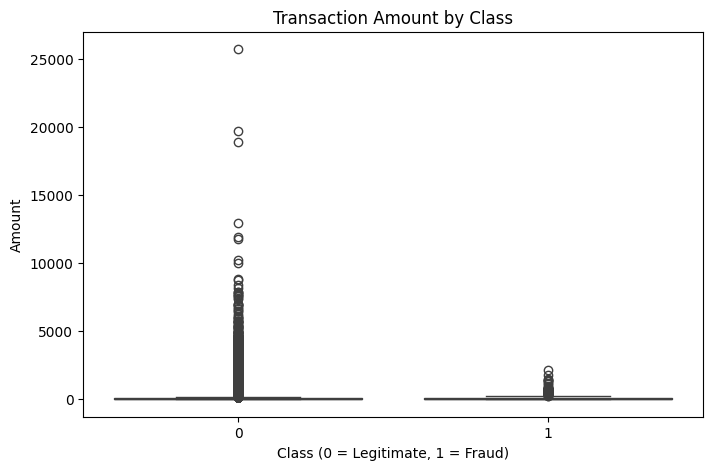

In [ ]:
# boxbot to analyze the relationship between class(fraud or real) and amount
plt.figure(figsize=(8,5))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.xlabel('Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Amount')
plt.show()

### Boxplot Interpretation — Amount by Class

Both legitimate and fraudulent transactions have median amounts close to 0,
meaning most transactions are small regardless of class.

However legitimate transactions have outliers reaching up to 25,000 while
fraud transactions max out around 1,500. This suggests fraudsters deliberately
keep transaction amounts small to avoid detection.

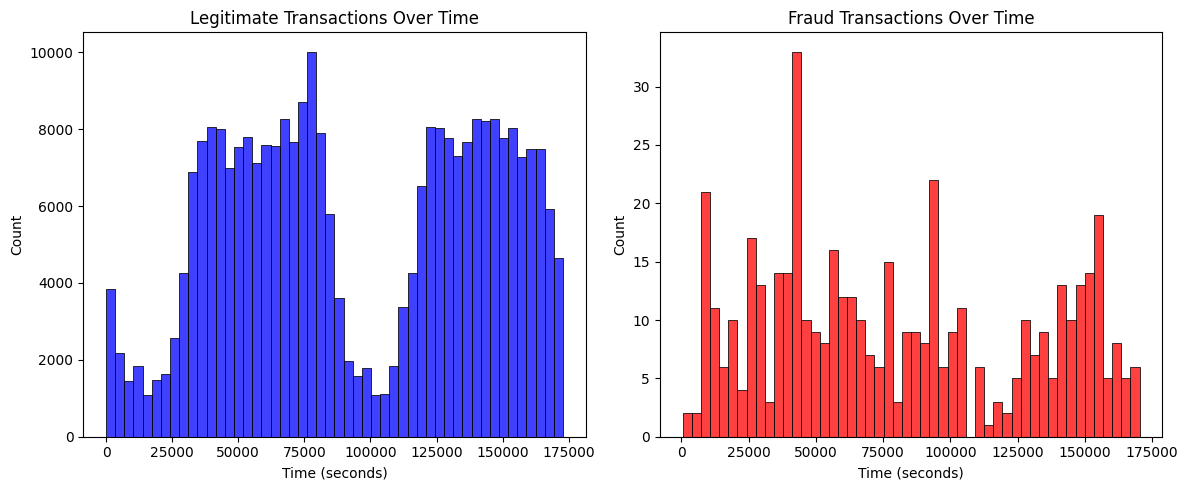

In [26]:
# to analyze trnsaction over time
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(df[df['Class']==0]['Time'], bins=50, color='blue', ax=axes[0])
axes[0].set_title('Legitimate Transactions Over Time')
axes[0].set_xlabel('Time (seconds)')

sns.histplot(df[df['Class']==1]['Time'], bins=50, color='red', ax=axes[1])
axes[1].set_title('Fraud Transactions Over Time')
axes[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()

### Time Distribution Interpretation

Legitimate transactions show a clear two peak pattern representing two days 
of data with a nighttime dip in between — matching normal human behavior.

Fraud transactions spike heavily at the start and remain active throughout 
without following the day/night pattern. This suggests fraud occurs 
disproportionately during odd hours when victims are less vigilant.

## Phase 5 — Feature Engineering

Feature Engineering is the process of transforming raw data into meaningful 
features that improve model performance.

V1-V28 are already PCA transformed with small values, but Amount and Time 
are on a completely different scale (Amount: 0-25000, Time: 0-175000). 
ML models can get confused by large numbers and give more importance to these 
columns just because of their size — not because they are actually more important.

In this phase we will:
- Scale Amount and Time columns to match the range of V1-V28
- Handle class imbalance using SMOTE

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# scaling amount to match PCA features
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
# scaling time to match PCA features
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Drop original Amount and Time columns
df = df.drop(['Amount', 'Time'], axis=1)

print("Scaling done! New shape:", df.shape)
print(df.head())

Scaling done! New shape: (283726, 31)
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V2

### Handling Class Imbalance using SMOTE

The dataset has a severe class imbalance with only 0.17% fraud cases.
Simply training a model on this data would result in a biased model that
ignores fraud cases entirely.

To fix this we use SMOTE — Synthetic Minority Oversampling Technique.
Instead of simply copying existing fraud cases, SMOTE creates brand new 
synthetic fraud samples by interpolating between existing fraud cases.
SMOTE uses the K-Nearest Neighbors (KNN) algorithm to find the k closest 
fraud transactions to each existing fraud case, then creates new synthetic 
samples along the line between them. This makes the dataset balanced without 
just repeating the same data.

Why not other techniques:

- Random Oversampling: Simply copies existing fraud rows repeatedly.
  This causes overfitting as the model just memorizes the same examples.

- Random Undersampling: Removes legitimate transactions to balance the data.
  This causes data loss — we lose valuable information from 280,000 transactions.

- SMOTE: Creates new synthetic fraud samples using KNN instead of copying or deleting.
  This balances the dataset without overfitting or losing data. 
  This is why SMOTE is the industry standard for imbalanced classification.

In [28]:

# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("Before SMOTE:")
print("Legitimate:", y.value_counts()[0])
print("Fraud:", y.value_counts()[1])

# Apply SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("\nAfter SMOTE:")
print("Legitimate:", y_resampled.value_counts()[0])
print("Fraud:", y_resampled.value_counts()[1])

Before SMOTE:
Legitimate: 283253
Fraud: 473

After SMOTE:
Legitimate: 283253
Fraud: 283253


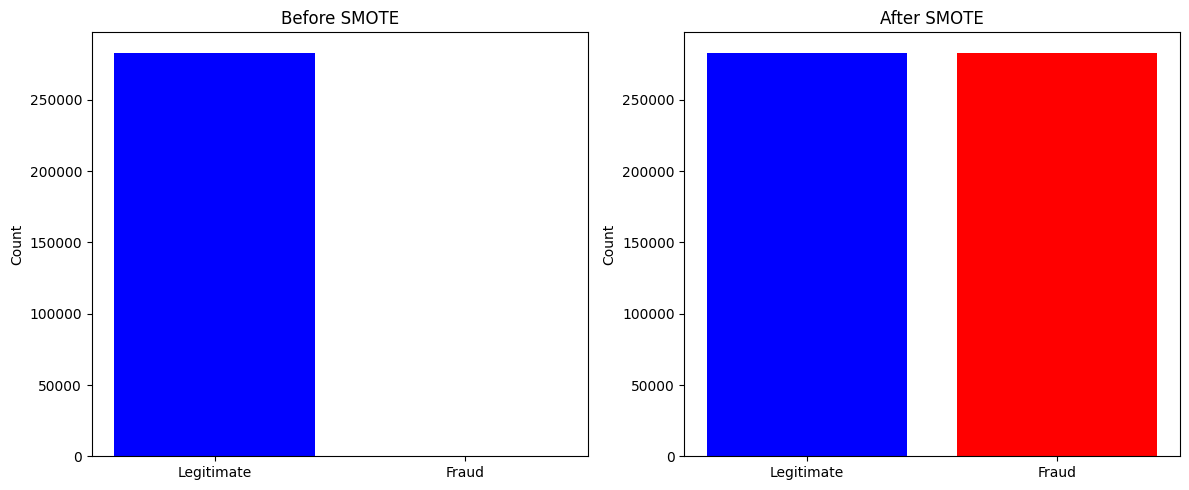

In [ ]:
# results after using SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12,5))
# Before SMOTE
axes[0].bar(['Legitimate', 'Fraud'], [y.value_counts()[0], y.value_counts()[1]], color=['blue', 'red'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

# After SMOTE
axes[1].bar(['Legitimate', 'Fraud'], [y_resampled.value_counts()[0], y_resampled.value_counts()[1]], color=['blue', 'red'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()